<a href="https://colab.research.google.com/github/linamendezh7/EjerciciosBIT-LinaMendez/blob/DataScience/Proyecto_final_Riesgo_Cardiaco_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto final**

# **Objetivo:**

---

Clasificar las relaciones entre estos factores y la probabilidad de una enfermedad cardíaca, identificando tendencias y posibles factores de riesgo.


# **Nomenclatura:**

---
*  cp: Chest pain
*  tresbps: Blood pressure
*  chol: Cholesterol
*  fbs: Blood Sugar
*  restecg: ECG result (Electrocardiogram)
*  thalach: Max heart rate
*  exang: Exercise angina
*  oldpeak: ST depression
*  slope: ST slope
*  ca: Major vessels
*  thai: Thalassemia
*  target: Heart attack risk






In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score

In [67]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [68]:
sns.set(style="whitegrid")

In [69]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [70]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Heart Attack Data Set (1).csv')

print("Dimensiones del dataset:", df.shape)
display(df.head())

Dimensiones del dataset: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# **Análisis exploratorio de los datos**

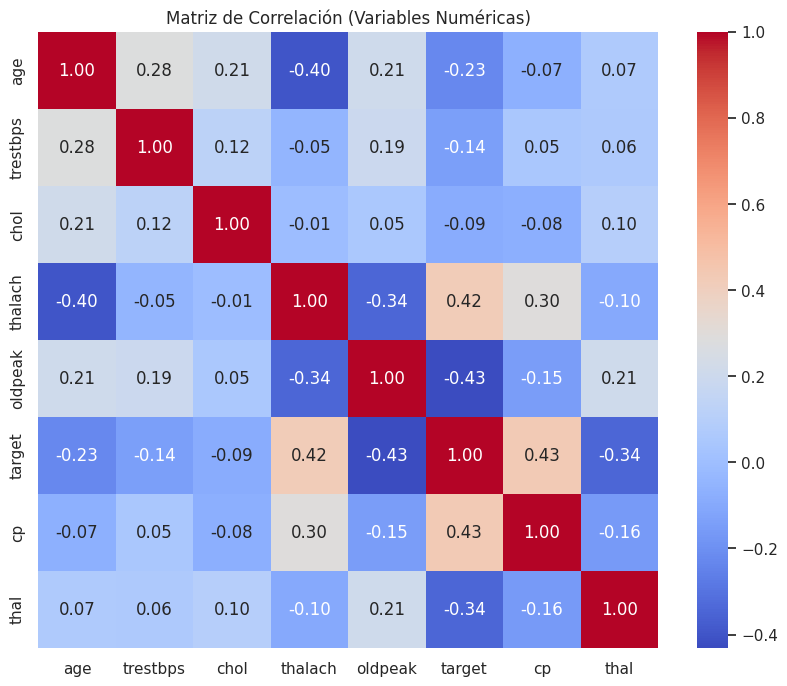

In [71]:
plt.figure(figsize=(10, 8))
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target','cp','thal']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación (Variables Numéricas)")
plt.show()

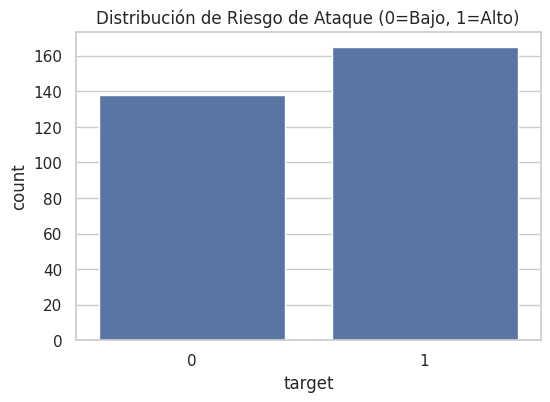

In [72]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Distribución de Riesgo de Ataque (0=Bajo, 1=Alto)')
plt.show()

In [73]:
print(df.shape)

(303, 14)


In [74]:
df = df.copy()

print("Primera vista del dataset:")
display(df.head())
print("\nInformación del dataset:")
df.info()
print("\nDistribución de la variable objetivo:")
print(df['target'].value_counts())

Primera vista del dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

Distribución de la variable objetivo:
target
1    165
0    138
Name: count, dtype: int64


In [75]:
data_riesgo = pd.DataFrame(df['target'].value_counts())
data_riesgo

,count
target,
1,165
0,138


In [76]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


# **Preprocesamiento**

In [77]:
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

In [78]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [79]:
# X: Conjunto de caracteristicas
# y: Variable Objetivo
X = df.drop('target', axis=1)
y = df['target']

# División en conjuntos de entrenamiento y prueba (usa stratify para respetar proporción de clases)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Escalado (muy importante para algunos modelos como KNN y SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Pregunta: ¿Por qué normalizamos los datos?

In [80]:
X_train.shape, X_test.shape

((242, 13), (61, 13))

In [81]:
BosqueAleatorio = RandomForestClassifier()
BosqueAleatorio

RandomForestClassifier()

In [82]:
BosqueAleatorio.fit(X_train, y_train)

RandomForestClassifier()

In [83]:
y_pred = BosqueAleatorio.predict(X_test)

              precision    recall  f1-score   support

           0       0.90      0.68      0.78        28
           1       0.78      0.94      0.85        33

    accuracy                           0.82        61
   macro avg       0.84      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61



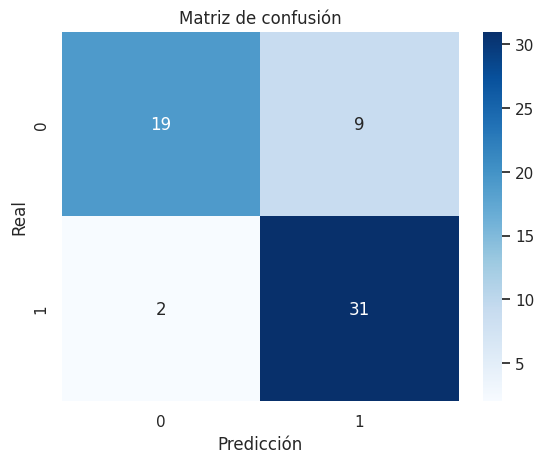

In [84]:
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()


Logistic Regression - Accuracy: 0.8033 | F1 Macro: 0.7967
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


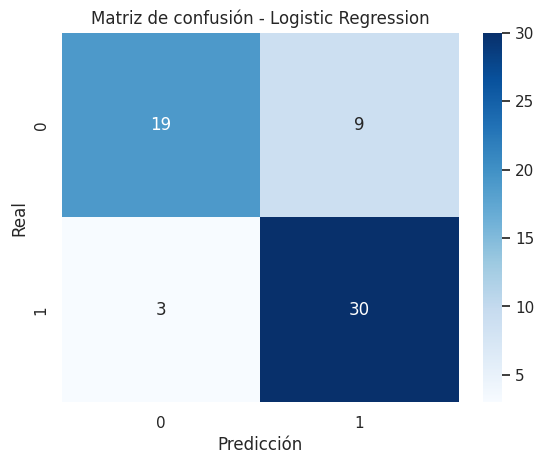


KNN - Accuracy: 0.8033 | F1 Macro: 0.7967
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



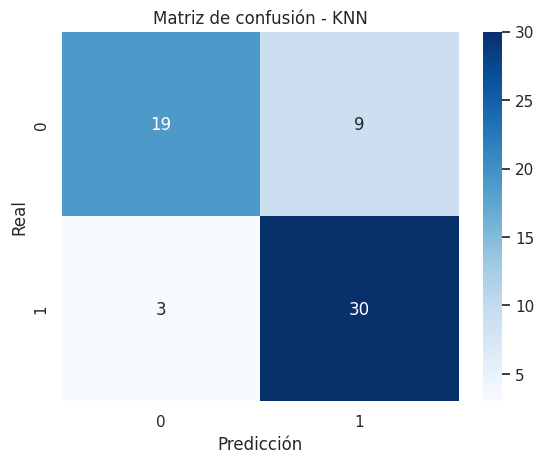


Decision Tree - Accuracy: 0.7049 | F1 Macro: 0.6984
              precision    recall  f1-score   support

           0       0.71      0.61      0.65        28
           1       0.70      0.79      0.74        33

    accuracy                           0.70        61
   macro avg       0.71      0.70      0.70        61
weighted avg       0.71      0.70      0.70        61



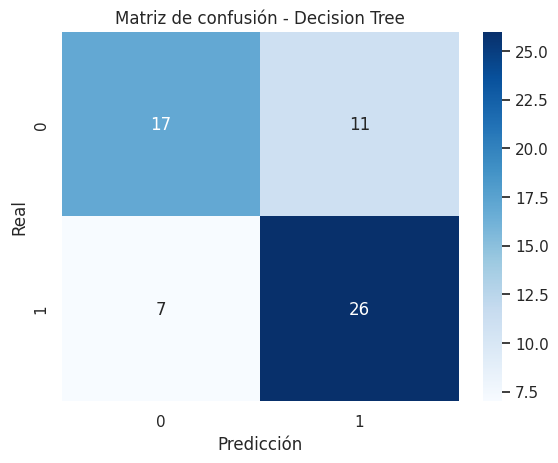


Random Forest - Accuracy: 0.8361 | F1 Macro: 0.8283
              precision    recall  f1-score   support

           0       0.95      0.68      0.79        28
           1       0.78      0.97      0.86        33

    accuracy                           0.84        61
   macro avg       0.87      0.82      0.83        61
weighted avg       0.86      0.84      0.83        61



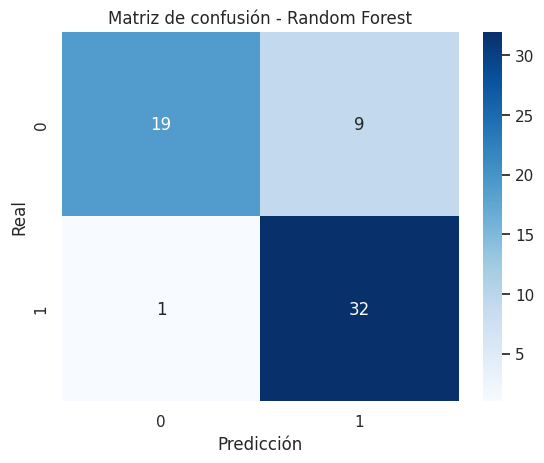


SVC (Linear) - Accuracy: 0.7869 | F1 Macro: 0.7783
              precision    recall  f1-score   support

           0       0.86      0.64      0.73        28
           1       0.75      0.91      0.82        33

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61



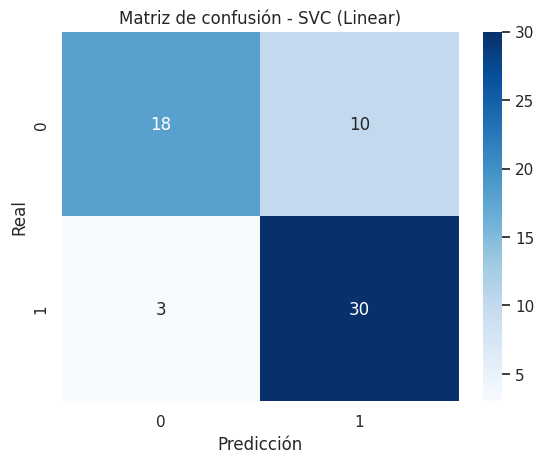


GaussianNB - Accuracy: 0.8197 | F1 Macro: 0.8147
              precision    recall  f1-score   support

           0       0.87      0.71      0.78        28
           1       0.79      0.91      0.85        33

    accuracy                           0.82        61
   macro avg       0.83      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61



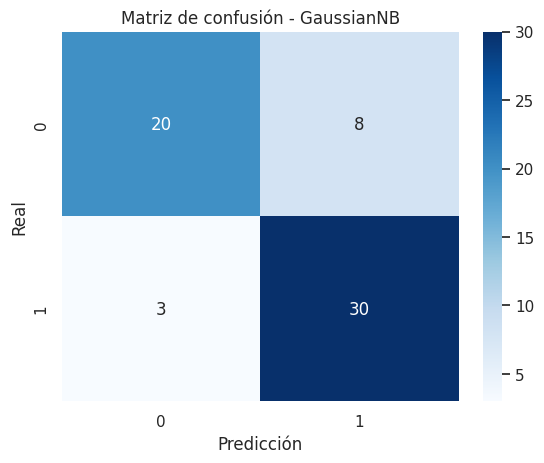

In [85]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, multi_class='multinomial', solver='lbfgs'),
    "KNN": KNeighborsClassifier(), ## K = Raiz cuadradada de N
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVC (Linear)": SVC(kernel='linear', probability=True, random_state=42),
    "GaussianNB": GaussianNB()
}
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train) # ENTRENAR
    y_pred = model.predict(X_test_scaled) # PREDICCION
    # EVALUAR MODELO
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    results[name] = {
        "model": model,
        "accuracy": acc,
        "f1_macro": f1_macro,
        "y_pred": y_pred
    }
    print(f"\n{name} - Accuracy: {acc:.4f} | F1 Macro: {f1_macro:.4f}")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de confusión - {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

# **Evaluación final**

In [86]:
# Definimos la rejilla de hiperparámetros a probar
param_grid = {
    'classifier__n_estimators': [100, 200],      # Número de árboles
    'classifier__max_depth': [None, 10, 20],     # Profundidad máxima
    'classifier__min_samples_split': [2, 5],     # Mínimo muestras para dividir
    'classifier__class_weight': ['balanced']     # Importante para dar peso a la clase minoritaria
}

print("Iniciando búsqueda de hiperparámetros (GridSearch)...")

Iniciando búsqueda de hiperparámetros (GridSearch)...


In [87]:
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [88]:
# Usamos 'recall' como scoring porque en salud es CRÍTICO minimizar los Falsos Negativos
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print(f"\nMejores parámetros encontrados: {grid_search.best_params_}")
print(f"Mejor Recall en Validación Cruzada: {grid_search.best_score_:.4f}")


Mejores parámetros encontrados: {'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Mejor Recall en Validación Cruzada: 0.8715



--- REPORTE DE CLASIFICACIÓN (TEST SET) ---
              precision    recall  f1-score   support

           0       0.90      0.64      0.75        28
           1       0.76      0.94      0.84        33

    accuracy                           0.80        61
   macro avg       0.83      0.79      0.79        61
weighted avg       0.82      0.80      0.80        61



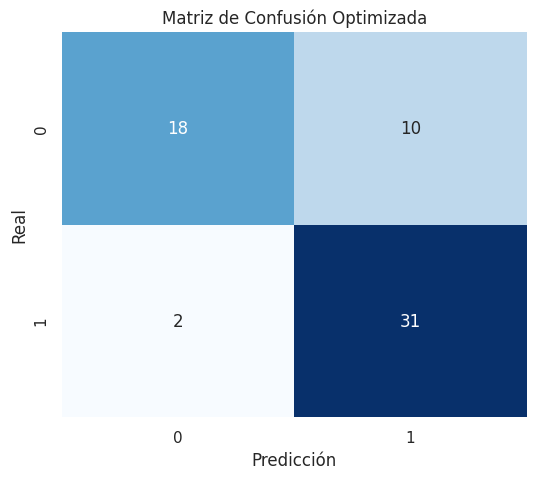

In [89]:
y_pred = best_model.predict(X_test)

print("\n--- REPORTE DE CLASIFICACIÓN (TEST SET) ---")
print(classification_report(y_test, y_pred))

# Matriz de Confusión Visual
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión Optimizada')
plt.show()

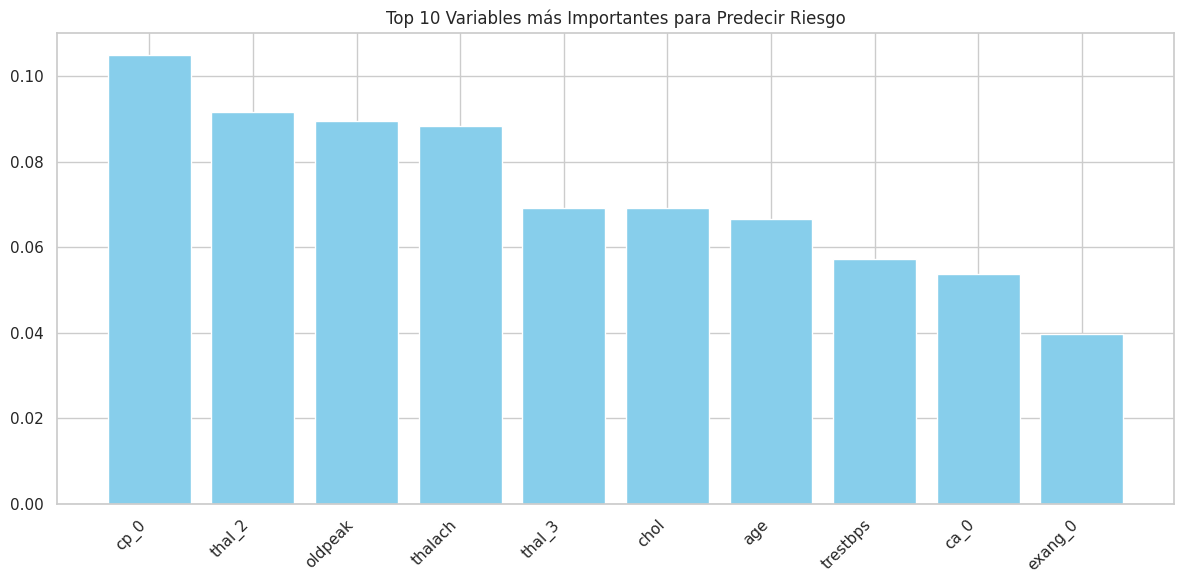

In [90]:
# Extraer nombres de features después del OneHotEncoding
ohe = best_model.named_steps['preprocessor'].named_transformers_['cat']
# Obtener nombres de categorías one-hot
ohe_feature_names = list(ohe.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + ohe_feature_names

# Obtener importancias del modelo
importances = best_model.named_steps['classifier'].feature_importances_
indices = np.argsort(importances)[::-1]

# Graficar Top 10 variables más importantes
plt.figure(figsize=(12, 6))
plt.title("Top 10 Variables más Importantes para Predecir Riesgo")
plt.bar(range(10), importances[indices[:10]], align="center", color='skyblue')
plt.xticks(range(10), [all_feature_names[i] for i in indices[:10]], rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [91]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve
# 1. OBTENER PROBABILIDADES (No solo predicciones 0/1)
# ---------------------------------------------------------
# Necesitamos la probabilidad de pertenecer a la clase 1 (Riesgo Alto)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

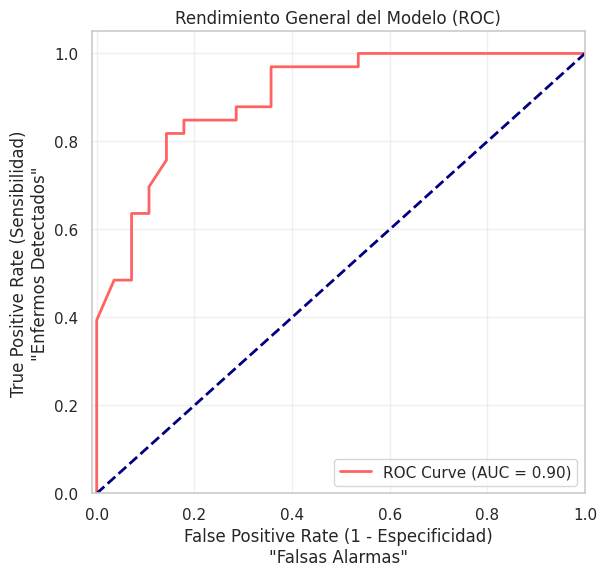

In [92]:
plt.figure(figsize=(14, 6))
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='#ff6361', lw=2, label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Especificidad)\n"Falsas Alarmas"')
plt.ylabel('True Positive Rate (Sensibilidad)\n"Enfermos Detectados"')
plt.title('Rendimiento General del Modelo (ROC)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

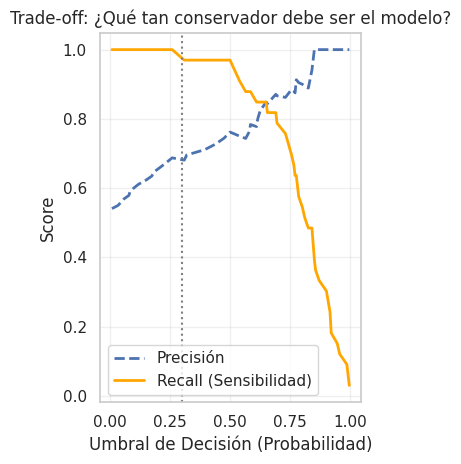

In [93]:
# --- GRÁFICO B: PRECISIÓN-RECALL VS UMBRAL ---
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)

plt.subplot(1, 2, 2)
plt.plot(thresholds_pr, precisions[:-1], "b--", label="Precisión", linewidth=2)
plt.plot(thresholds_pr, recalls[:-1], "#ffa600", label="Recall (Sensibilidad)", linewidth=2)
plt.xlabel("Umbral de Decisión (Probabilidad)")
plt.ylabel("Score")
plt.title("Trade-off: ¿Qué tan conservador debe ser el modelo?")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
# Línea vertical de ejemplo en 0.3
plt.axvline(x=0.3, color='grey', linestyle=':', label='Umbral Sugerido (0.3)')

plt.tight_layout()
plt.show()

# **Desarrollo APP**

In [98]:
import os

# Esto limpia cualquier error de intentos anteriores
os.system("pkill -9 streamlit")
os.system("pkill -9 npx")

print("✅ PASO 1 COMPLETADO: La mesa está limpia.")

✅ PASO 1 COMPLETADO: La mesa está limpia.


In [99]:
import joblib

# Guardamos tu modelo optimizado (el pipeline)
joblib.dump(best_model, 'modelo_riesgo_cardiaco.joblib')
print("✅ PASO 2 COMPLETADO: Modelo guardado.")

✅ PASO 2 COMPLETADO: Modelo guardado.


In [100]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# Cargamos el modelo que guardamos en el Paso 2
modelo = joblib.load('/content/modelo_riesgo_cardiaco.joblib')

st.set_page_config(page_title="Analizador Cardiaco", layout="centered")
st.title("🩺 Diagnóstico de Riesgo Cardiaco")

with st.form("formulario"):
    st.subheader("Ingrese los datos del paciente:")
    age = st.number_input("Edad", 1, 100, 45)
    sex = st.selectbox("Sexo", [0, 1], format_func=lambda x: "Masculino" if x==1 else "Femenino")
    cp = st.selectbox("Dolor de Pecho (0-3)", [0, 1, 2, 3])
    trestbps = st.number_input("Presión Arterial", 80, 200, 120)
    chol = st.number_input("Colesterol", 100, 600, 200)
    fbs = st.selectbox("Azúcar > 120 mg/dl", [0, 1])
    restecg = st.selectbox("Electrocardiograma (0-2)", [0, 1, 2])
    thalach = st.number_input("Frecuencia Cardiaca Máxima", 60, 220, 150)
    exang = st.selectbox("Angina por ejercicio", [0, 1])
    oldpeak = st.number_input("Depresión ST (Oldpeak)", 0.0, 6.0, 1.0)
    slope = st.selectbox("Pendiente ST (0-2)", [0, 1, 2])
    ca = st.selectbox("Vasos principales (0-4)", [0, 1, 2, 3, 4])
    thal = st.selectbox("Thalassemia (0-3)", [0, 1, 2, 3])

    boton = st.form_submit_button("ANALIZAR AHORA")

if boton:
    # Creamos la tabla de datos para el modelo
    datos = pd.DataFrame([[age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal]],
                         columns=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'])

    pred = modelo.predict(datos)[0]
    prob = modelo.predict_proba(datos)[0][1]

    if pred == 1:
        st.error(f"⚠️ ALTO RIESGO (Probabilidad: {prob:.2%})")
    else:
        st.success(f"✅ BAJO RIESGO (Probabilidad: {prob:.2%})")

Overwriting app.py


In [101]:
print("⏳ Tu IP de acceso es:")
!wget -q -O - ipv4.icanhazip.com
print("\n👆 COPIA la IP y pégala en el enlace de abajo:")

!pip install -q streamlit scikit-learn pandas joblib
!streamlit run app.py & npx localtunnel --port 8501

⏳ Tu IP de acceso es:
34.16.193.97

👆 COPIA la IP y pégala en el enlace de abajo:
⠙⠹⠸⠼

⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸your url is: https://lucky-parts-itch.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.16.193.97:8501

  Stopping...
^C


In [ ]:
import os
import joblib
import pandas as pd

# 1. LIMPIEZA DE PROCESOS
print("🧹 Limpiando procesos antiguos...")
os.system("pkill -9 streamlit")
os.system("pkill -9 npx")
os.system("rm -f app.py") # Borramos app vieja por seguridad

# 2. GUARDAR MODELO (Verificamos que exista best_model)
print("💾 Guardando modelo...")
try:
    # Intenta usar la variable best_model si existe en memoria
    if 'best_model' in globals():
        joblib.dump(best_model, 'modelo_riesgo_cardiaco.joblib')
        print("✅ Modelo guardado desde la memoria.")
    elif os.path.exists('modelo_riesgo_cardiaco.joblib'):
        print("⚠️ 'best_model' no está en memoria, pero el archivo .joblib ya existe. Usaremos ese.")
    else:
        raise ValueError("No existe 'best_model' en memoria ni archivo .joblib. Entrena el modelo antes.")
except Exception as e:
    print(f"❌ Error crítico: {e}")
    # Detenemos aquí si no hay modelo, no tiene sentido seguir
    pass

# 3. ESCRIBIR APP.PY (Usando Python directo para evitar errores de sintaxis)
print("📝 Generando código de la aplicación...")

app_code = r"""
import streamlit as st
import pandas as pd
import joblib
import os

# Configuración
st.set_page_config(page_title="Analizador Cardiaco", layout="centered")

st.title("🩺 Diagnóstico de Riesgo Cardiaco")

# Carga del modelo
if not os.path.exists('modelo_riesgo_cardiaco.joblib'):
    st.error("❌ No se encontró el archivo del modelo. Asegúrate de haberlo guardado.")
    st.stop()

modelo = joblib.load('modelo_riesgo_cardiaco.joblib')

# Formulario
with st.form("formulario_riesgo"):
    st.subheader("Datos del Paciente")

    col1, col2 = st.columns(2)

    with col1:
        age = st.number_input("Edad", 1, 100, 45)
        sex = st.selectbox("Sexo", [0, 1], format_func=lambda x: "Femenino" if x==0 else "Masculino")
        cp = st.selectbox("Dolor de Pecho (0-3)", [0, 1, 2, 3], help="0:Típico, 1:Atípico, 2:No anginoso, 3:Asintomático")
        trestbps = st.number_input("Presión Arterial", 80, 200, 120)
        chol = st.number_input("Colesterol", 100, 600, 200)
        fbs = st.selectbox("Azúcar > 120 mg/dl", [0, 1], format_func=lambda x: "No" if x==0 else "Sí")
        restecg = st.selectbox("Electrocardiograma (0-2)", [0, 1, 2])

    with col2:
        thalach = st.number_input("Frecuencia Cardiaca Máx", 60, 220, 150)
        exang = st.selectbox("Angina por ejercicio", [0, 1], format_func=lambda x: "No" if x==0 else "Sí")
        oldpeak = st.number_input("Depresión ST", 0.0, 6.0, 1.0)
        slope = st.selectbox("Pendiente ST (0-2)", [0, 1, 2])
        ca = st.selectbox("Vasos principales (0-4)", [0, 1, 2, 3, 4])
        thal = st.selectbox("Thalassemia (0-3)", [0, 1, 2, 3])

    # Botón DE DENTRO del form
    boton = st.form_submit_button("ANALIZAR AHORA", type="primary")

if boton:
    # DataFrame con nombres de columnas exactos
    datos = pd.DataFrame([[age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal]],
                         columns=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'])

    try:
        pred = modelo.predict(datos)[0]
        prob = modelo.predict_proba(datos)[0][1]

        st.divider()
        if prob > 0.3: # Umbral ajustado
            st.error(f"⚠️ ALTO RIESGO DETECTADO (Probabilidad: {prob:.1%})")
            st.warning("Se recomienda visitar a un cardiólogo.")
        else:
            st.success(f"✅ BAJO RIESGO (Probabilidad: {prob:.1%})")
            st.info("Mantener hábitos saludables.")

    except Exception as e:
        st.error(f"Error en la predicción: {e}")
"""

with open("app.py", "w") as f:
    f.write(app_code)

print("✅ Archivo app.py creado exitosamente.")

# 4. LANZAR SERVIDOR
print("\n" + "="*40)
print("🔑 TU IP DE ACCESO ES:")
!wget -q -O - ipv4.icanhazip.com
print("="*40)
print("👇 Haz clic en el enlace, pega la IP y dale Submit.")

!pip install -q streamlit scikit-learn pandas joblib
!streamlit run app.py & npx localtunnel --port 8501

🧹 Limpiando procesos antiguos...
💾 Guardando modelo...
✅ Modelo guardado desde la memoria.
📝 Generando código de la aplicación...
✅ Archivo app.py creado exitosamente.

🔑 TU IP DE ACCESO ES:
34.16.193.97
👇 Haz clic en el enlace, pega la IP y dale Submit.
⠙

⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸your url is: https://dirty-dogs-hammer.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.16.193.97:8501

